
# Práctica 1 · Minería de Datos aplicada: deserción y éxito académico
**Universidad Estatal Amazónica · UEA-L-UFPTI-009** · Integrantes: _completar_

**Cómo usar este notebook:** ejecuta las celdas en orden (*Run All* o una por una). Las celdas marcadas **Interpretación (completar)** son tuyas: escribe ahí lo que observas, porque eso es lo que va al documento.

| Semanas | Qué hacer |
|---|---|
| 1–2 | Definición del problema, objetivos, alcance, elevator pitch (documento) · Secciones 0–1 |
| 3–5 | Calidad de datos, descriptivas y visualizaciones · Secciones 2–4 |
| 6–7 | Variables derivadas, preprocesamiento, partición · Secciones 5–6 |
| 8–11 | Modelado · Sección 7 |
| 12–13 | Evaluación, validación e interpretación · Secciones 8–9 |
| 14 | Artículo IEEE short paper |
| 15 | Repositorio GitHub, bibliografía APA, anexos, unir todo en un PDF (PDF24/PDFgear) |
| 16 | Entrega en Moodle |


## 0. Configuración

In [39]:
print("Registros:", len(df), "| Columnas:", df.shape[1])
print("Variables con nulos:", int((nulos['% nulos'] > 0).sum()), "| max % nulos:", nulos['% nulos'].max())
print(f"Duplicados: {dup_n} ({dup_p} %)")
print("\nTop 8 atípicos (IQR):\n", atipicos.head(8).to_string(index=False))
print("\nDistribución del objetivo:\n", dist.to_string())
print("\nComparación de modelos:\n", resultados.to_string(index=False))
print("\nMejor modelo (escenario B):", mejor)
print("\nTop 10 variables (RF):\n", imp.head(10).round(4).to_string())
print(f"\nK-means (K={K}) perfiles:\n", perfil.to_string())
print("\nK-means vs objetivo (%):\n", riesgo.to_string())

Registros: 4424 | Columnas: 43
Variables con nulos: 0 | max % nulos: 0.0
Duplicados: 0 (0.0 %)

Top 8 atípicos (IQR):
                                       variable  atipicos  % atipicos
              Curricular units 2nd sem (grade)       877       19.82
              Curricular units 1st sem (grade)       726       16.41
           Curricular units 1st sem (credited)       577       13.04
           Curricular units 2nd sem (credited)       530       11.98
                             Age at enrollment       441        9.97
           Curricular units 1st sem (enrolled)       424        9.58
           Curricular units 2nd sem (enrolled)       369        8.34
Curricular units 1st sem (without evaluations)       294        6.65

Distribución del objetivo:
              n      %
Target               
Graduate  2209  49.93
Dropout   1421  32.12
Enrolled   794  17.95

Comparación de modelos:
        Escenario              Modelo  Accuracy (test)  F1 macro (test)  Precision macro (test) 

In [40]:
import sys

!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn ucimlrepo


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [41]:
import warnings
from pathlib import Path
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

ROOT = Path("..") if Path("../data").exists() else Path(".")
RAW, PROC = ROOT / "data/raw", ROOT / "data/processed"
FIG, TAB = ROOT / "reports/figures", ROOT / "reports/tables"
for p in (RAW, PROC, FIG, TAB):
    p.mkdir(parents=True, exist_ok=True)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

ROOT = Path("..") if Path("../data").exists() else Path(".")
RAW, PROC = ROOT / "data/raw", ROOT / "data/processed"
FIG, TAB = ROOT / "reports/figures", ROOT / "reports/tables"
for p in (RAW, PROC, FIG, TAB):
    p.mkdir(parents=True, exist_ok=True)

## 1. Carga de datos

In [42]:
csv_path = RAW / "dropout.csv"
if csv_path.exists():
    df = pd.read_csv(csv_path, sep=None, engine="python")   # detecta ; o ,
else:
    from ucimlrepo import fetch_ucirepo
    ds = fetch_ucirepo(id=697)                               # UCI: Predict Students' Dropout and Academic Success
    df = pd.concat([ds.data.features, ds.data.targets], axis=1)
    df.to_csv(csv_path, index=False)

df.columns = [c.strip() for c in df.columns]
print("Registros y columnas:", df.shape)
df.head()

Registros y columnas: (4424, 37)


,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [43]:
def col(*keys):
    """Busca una columna cuyo nombre contenga todas las palabras clave (sin distinguir mayúsculas)."""
    for c in df.columns:
        if all(k.lower() in c.lower() for k in keys):
            return c
    raise KeyError(f"No se encontró columna con {keys}. Revisa df.columns")

TARGET = col("target")

# Variables que son CÓDIGOS (categóricas) aunque vengan como enteros
CAT_KEYS = ["marital", "application mode", "application order", "course", "attendance",
            "previous qualification", "nacionality", "nationality", "mother's", "father's",
            "displaced", "special needs", "debtor", "tuition", "gender", "scholarship", "international"]
cat_cols = [c for c in df.columns if c != TARGET and any(k in c.lower() for k in CAT_KEYS)
            and "grade" not in c.lower()]
num_cols = [c for c in df.columns if c != TARGET and c not in cat_cols]
print(f"{len(cat_cols)} categóricas · {len(num_cols)} numéricas")

18 categóricas · 18 numéricas


## 2. Calidad de datos

In [44]:
# 2.1 Porcentaje de nulos por variable
nulos = (df.isna().mean() * 100).round(2).rename("% nulos").to_frame()
nulos.to_csv(TAB / "nulos_por_variable.csv")
print("Variables con nulos:", int((nulos["% nulos"] > 0).sum()), "de", len(nulos))
nulos.sort_values("% nulos", ascending=False).head(10)

Variables con nulos: 0 de 37


,% nulos
Marital Status,0.0
Application mode,0.0
Application order,0.0
Course,0.0
Daytime/evening attendance,0.0
Previous qualification,0.0
Previous qualification (grade),0.0
Nacionality,0.0
Mother's qualification,0.0
Father's qualification,0.0


In [45]:
# 2.2 Duplicados: cantidad y porcentaje
dup_n = int(df.duplicated().sum())
dup_p = round(dup_n / len(df) * 100, 2)
print(f"Registros duplicados: {dup_n} ({dup_p} %)")

Registros duplicados: 0 (0.0 %)


In [46]:
# 2.3 Valores atípicos (regla IQR) en variables numéricas
filas = []
for c in num_cols:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    n_out = int(((df[c] < q1 - 1.5 * iqr) | (df[c] > q3 + 1.5 * iqr)).sum())
    filas.append({"variable": c, "atipicos": n_out, "% atipicos": round(n_out / len(df) * 100, 2)})
atipicos = pd.DataFrame(filas).sort_values("atipicos", ascending=False)
atipicos.to_csv(TAB / "atipicos_iqr.csv", index=False)
atipicos.head(10)

,variable,atipicos,% atipicos
13,Curricular units 2nd sem (grade),877,19.82
7,Curricular units 1st sem (grade),726,16.41
3,Curricular units 1st sem (credited),577,13.04
9,Curricular units 2nd sem (credited),530,11.98
2,Age at enrollment,441,9.97
4,Curricular units 1st sem (enrolled),424,9.58
10,Curricular units 2nd sem (enrolled),369,8.34
8,Curricular units 1st sem (without evaluations),294,6.65
14,Curricular units 2nd sem (without evaluations),282,6.37
6,Curricular units 1st sem (approved),180,4.07


**Decisión sobre atípicos (completar):** explica aquí si los conservas o los tratas, y por qué.
Ejemplo: una edad alta al ingreso es un caso legítimo (estudiante adulto), no un error de captura.

## 3. Estadísticas descriptivas

In [47]:
desc = df[num_cols].describe().T.round(2)
desc.to_csv(TAB / "estadisticas_descriptivas.csv")
display(desc.head(15))

dist = df[TARGET].value_counts().to_frame("n")
dist["%"] = (dist["n"] / len(df) * 100).round(2)
dist

,count,mean,std,min,25%,50%,75%,max
Previous qualification (grade),4424.0,132.61,13.19,95.0,125.00,133.10,140.00,190.00
Admission grade,4424.0,126.98,14.48,95.0,117.90,126.10,134.80,190.00
Age at enrollment,4424.0,23.27,7.59,17.0,19.00,20.00,25.00,70.00
Curricular units 1st sem (credited),4424.0,0.71,2.36,0.0,0.00,0.00,0.00,20.00
Curricular units 1st sem (enrolled),4424.0,6.27,2.48,0.0,5.00,6.00,7.00,26.00
Curricular units 1st sem (evaluations),4424.0,8.30,4.18,0.0,6.00,8.00,10.00,45.00
Curricular units 1st sem (approved),4424.0,4.71,3.09,0.0,3.00,5.00,6.00,26.00
Curricular units 1st sem (grade),4424.0,10.64,4.84,0.0,11.00,12.29,13.40,18.88
Curricular units 1st sem (without evaluations),4424.0,0.14,0.69,0.0,0.00,0.00,0.00,12.00
Curricular units 2nd sem (credited),4424.0,0.54,1.92,0.0,0.00,0.00,0.00,19.00


,n,%
Target,,
Graduate,2209,49.93
Dropout,1421,32.12
Enrolled,794,17.95


## 4. Visualizaciones

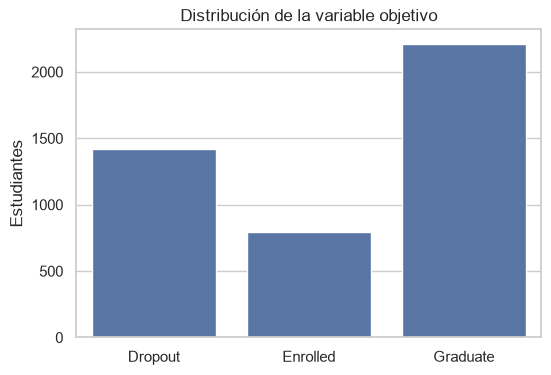

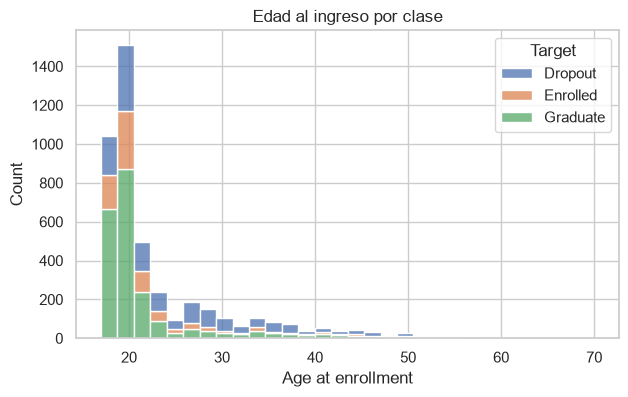

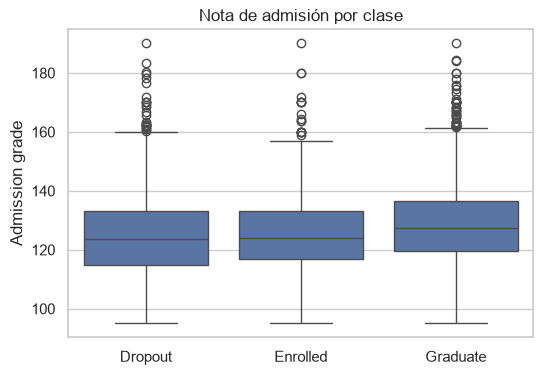

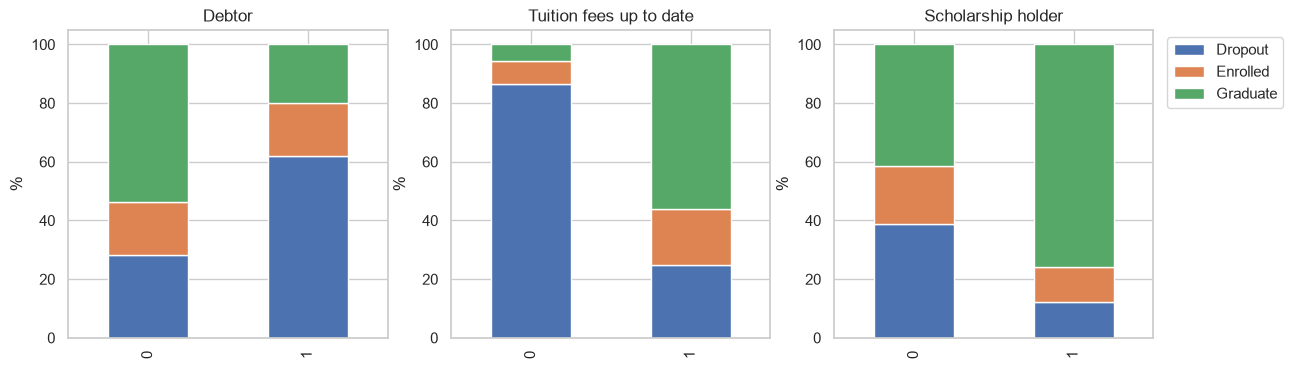

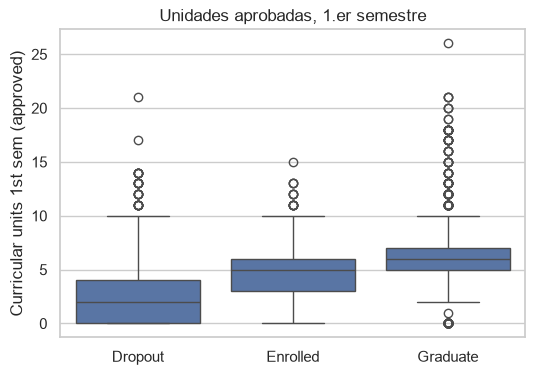

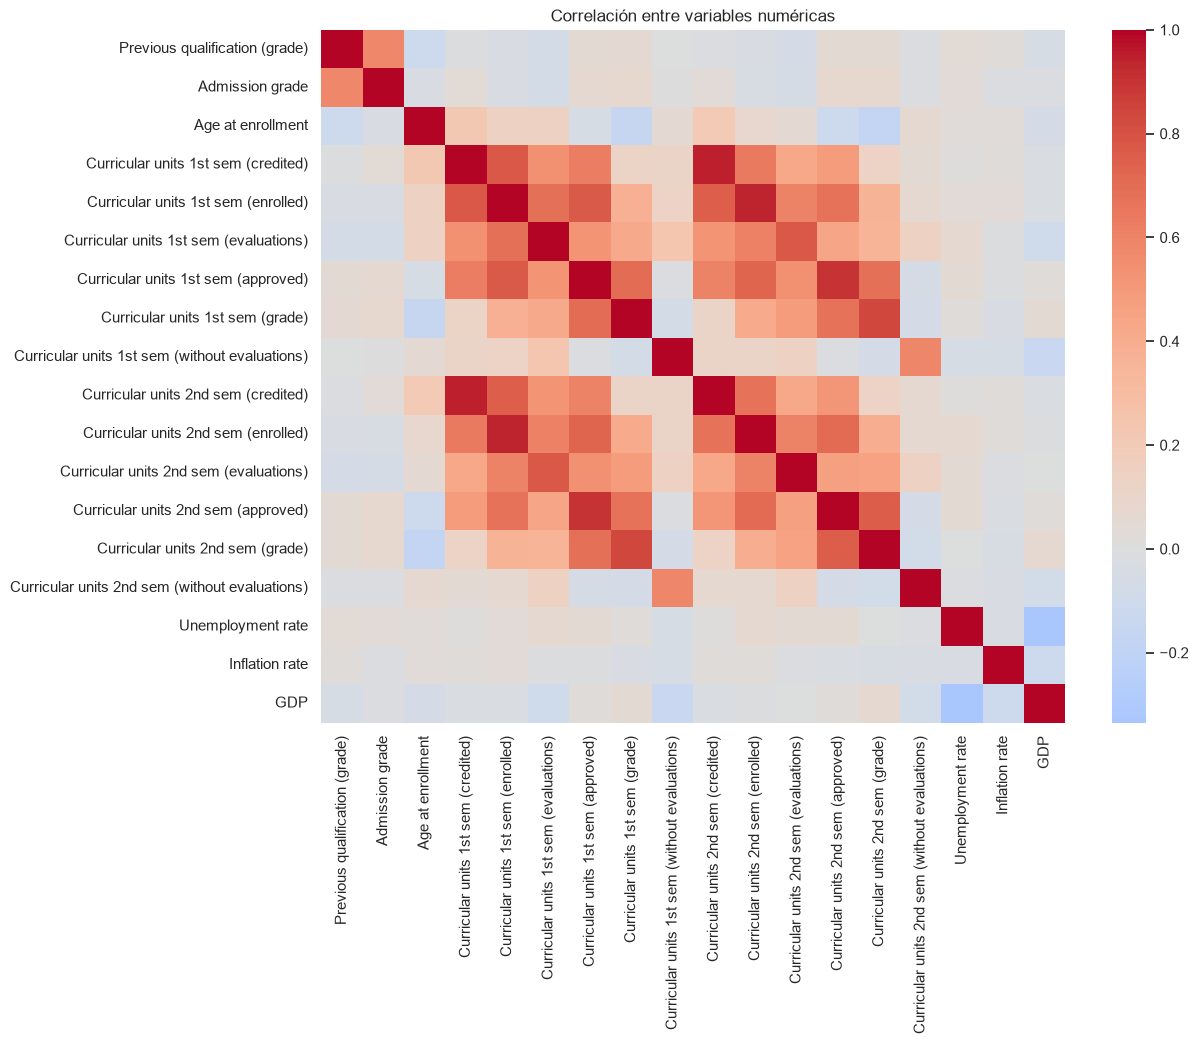

In [48]:
age, adm = col("age"), col("admission", "grade")
debtor, tuition, schol = col("debtor"), col("tuition"), col("scholarship")
appr1 = col("1st sem", "approved")
orden = sorted(df[TARGET].unique())

# 1. Distribución de la clase objetivo
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x=TARGET, order=orden, ax=ax)
ax.set_title("Distribución de la variable objetivo"); ax.set_xlabel(""); ax.set_ylabel("Estudiantes")
fig.savefig(FIG / "01_distribucion_objetivo.png", dpi=150, bbox_inches="tight"); plt.show()

# 2. Edad al ingreso por clase
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(data=df, x=age, hue=TARGET, hue_order=orden, bins=30, multiple="stack", ax=ax)
ax.set_title("Edad al ingreso por clase")
fig.savefig(FIG / "02_edad_por_clase.png", dpi=150, bbox_inches="tight"); plt.show()

# 3. Nota de admisión por clase
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=df, x=TARGET, y=adm, order=orden, ax=ax)
ax.set_title("Nota de admisión por clase"); ax.set_xlabel("")
fig.savefig(FIG / "03_nota_admision.png", dpi=150, bbox_inches="tight"); plt.show()

# 4. Tasa de resultado según factores financieros
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, c in zip(axes, [debtor, tuition, schol]):
    pd.crosstab(df[c], df[TARGET], normalize="index").mul(100).plot(kind="bar", stacked=True, ax=ax, legend=False)
    ax.set_title(c); ax.set_xlabel(""); ax.set_ylabel("%")
axes[-1].legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.savefig(FIG / "04_factores_financieros.png", dpi=150, bbox_inches="tight"); plt.show()

# 5. Unidades aprobadas en el 1.er semestre por clase
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=df, x=TARGET, y=appr1, order=orden, ax=ax)
ax.set_title("Unidades aprobadas, 1.er semestre"); ax.set_xlabel("")
fig.savefig(FIG / "05_aprobadas_1s.png", dpi=150, bbox_inches="tight"); plt.show()

# 6. Mapa de calor de correlación (numéricas)
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(df[num_cols].corr(), cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlación entre variables numéricas")
fig.savefig(FIG / "06_correlacion.png", dpi=150, bbox_inches="tight"); plt.show()

**Interpretación (completar):** escribe 1–2 frases por gráfico con lo que observas; irán al documento y al artículo.

## 5. Variables derivadas (feature engineering)

In [49]:
e1, a1, g1 = col("1st sem", "enrolled"), col("1st sem", "approved"), col("1st sem", "grade")
e2, a2, g2 = col("2nd sem", "enrolled"), col("2nd sem", "approved"), col("2nd sem", "grade")

df["tasa_aprob_1s"] = (df[a1] / df[e1].replace(0, np.nan)).fillna(0)      # aprobadas / inscritas
df["tasa_aprob_2s"] = (df[a2] / df[e2].replace(0, np.nan)).fillna(0)
df["variacion_nota"] = df[g2] - df[g1]                                    # mejora o caída entre semestres
df["total_aprobadas"] = df[a1] + df[a2]
df["riesgo_financiero"] = ((df[debtor] == 1) | (df[tuition] == 0)).astype(int)  # deudor o matrícula no al día

num_cols += ["tasa_aprob_1s", "tasa_aprob_2s", "variacion_nota", "total_aprobadas"]
cat_cols += ["riesgo_financiero"]
df[["tasa_aprob_1s", "tasa_aprob_2s", "variacion_nota", "total_aprobadas", "riesgo_financiero"]].describe().round(2)

,tasa_aprob_1s,tasa_aprob_2s,variacion_nota,total_aprobadas,riesgo_financiero
count,4424.00,4424.00,4424.00,4424.00,4424.00
mean,0.70,0.66,-0.41,9.14,0.18
std,0.37,0.38,2.89,5.96,0.38
min,0.00,0.00,-16.14,0.00,0.00
25%,0.50,0.40,-0.60,5.00,0.00
50%,0.83,0.83,0.00,10.00,0.00
75%,1.00,1.00,0.45,12.00,0.00
max,1.00,1.00,16.00,43.00,1.00


## 6. Preprocesamiento y partición
Se **codifica** (one-hot) y se **normaliza** (StandardScaler) con un `ColumnTransformer` que se ajusta **solo con el entrenamiento** (evita fuga de datos).

In [50]:
X, y = df.drop(columns=[TARGET]), df[TARGET]
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)

prep = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])
Xtr_t = prep.fit_transform(X_tr)
Xte_t = prep.transform(X_te)
print(f"Entrenamiento: {X_tr.shape[0]} (80 %) · Prueba: {X_te.shape[0]} (20 %)")
print(f"Dimensión tras codificación: {Xtr_t.shape[1]} columnas")
print(y_tr.value_counts(normalize=True).round(3).to_dict())

Entrenamiento: 3539 (80 %) · Prueba: 885 (20 %)
Dimensión tras codificación: 257 columnas
{'Graduate': 0.499, 'Dropout': 0.321, 'Enrolled': 0.179}


In [51]:
# Escenario "solo datos de ingreso" (detección temprana) para comparar luego en el modelado
cols_ingreso = [c for c in X.columns if "curricular" not in c.lower()
                and c not in ["tasa_aprob_1s", "tasa_aprob_2s", "variacion_nota", "total_aprobadas"]]
print(len(cols_ingreso), "columnas disponibles al momento del ingreso")

# Guardar datos con variables derivadas para los siguientes notebooks
df.to_csv(PROC / "dropout_procesado.csv", index=False)

25 columnas disponibles al momento del ingreso


# 7. Modelado
Tres técnicas supervisadas dentro de un `Pipeline` (el preprocesamiento se ajusta solo con los datos de entrenamiento) y dos escenarios:
- **A · Solo ingreso:** información disponible al matricularse (detección temprana).
- **B · Completo:** ingreso + rendimiento de los dos primeros semestres.

**Para el documento:** copia la tabla de parámetros (celda siguiente), indica la partición 80/20 estratificada y `random_state=42`.

In [52]:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report)

MODELOS = {
    "Árbol de decisión":   DecisionTreeClassifier(max_depth=6, min_samples_leaf=20, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest":       RandomForestClassifier(n_estimators=300, min_samples_leaf=3, class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE),
    "Regresión logística": LogisticRegression(C=1.0, max_iter=2000, class_weight="balanced"),
}
params = pd.DataFrame({n: {k: v for k, v in m.get_params().items()
                           if k in ["max_depth","min_samples_leaf","class_weight","n_estimators","C","max_iter","random_state"]}
                       for n, m in MODELOS.items()}).T
params.to_csv(TAB / "parametros_modelos.csv")
params

,class_weight,max_depth,min_samples_leaf,random_state,n_estimators,C,max_iter
Árbol de decisión,balanced,6,20,42,NaN,NaN,NaN
Random Forest,balanced,None,3,42,300,NaN,NaN
Regresión logística,balanced,NaN,NaN,None,NaN,1.0,2000


In [53]:
def armar_pipeline(modelo, columnas):
    nc = [c for c in num_cols if c in columnas]
    cc = [c for c in cat_cols if c in columnas]
    prep_ = ColumnTransformer([("num", StandardScaler(), nc),
                               ("cat", OneHotEncoder(handle_unknown="ignore"), cc)])
    return Pipeline([("prep", prep_), ("modelo", modelo)])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
ESCENARIOS = {"A · Solo ingreso": cols_ingreso, "B · Completo": list(X.columns)}

filas, ajustados = [], {}
for esc, cols in ESCENARIOS.items():
    for nombre, modelo in MODELOS.items():
        pipe = armar_pipeline(modelo, cols)
        cvr = cross_validate(pipe, X_tr[cols], y_tr, cv=cv, scoring=["accuracy", "f1_macro"], n_jobs=-1)
        pipe.fit(X_tr[cols], y_tr)
        pred = pipe.predict(X_te[cols])
        ajustados[(esc, nombre)] = (pipe, pred, cols)
        filas.append({
            "Escenario": esc, "Modelo": nombre,
            "Accuracy (test)": accuracy_score(y_te, pred),
            "F1 macro (test)": f1_score(y_te, pred, average="macro"),
            "Precision macro (test)": precision_score(y_te, pred, average="macro"),
            "Recall macro (test)": recall_score(y_te, pred, average="macro"),
            "Accuracy CV-5 (media)": cvr["test_accuracy"].mean(), "Accuracy CV-5 (desv)": cvr["test_accuracy"].std(),
            "F1 macro CV-5 (media)": cvr["test_f1_macro"].mean(), "F1 macro CV-5 (desv)": cvr["test_f1_macro"].std(),
        })
resultados = pd.DataFrame(filas).round(3)
resultados.to_csv(TAB / "comparacion_modelos.csv", index=False)
resultados

,Escenario,Modelo,Accuracy (test),F1 macro (test),Precision macro (test),Recall macro (test),Accuracy CV-5 (media),Accuracy CV-5 (desv),F1 macro CV-5 (media),F1 macro CV-5 (desv)
0,A · Solo ingreso,Árbol de decisión,0.493,0.498,0.592,0.545,0.503,0.020,0.499,0.017
1,A · Solo ingreso,Random Forest,0.589,0.548,0.549,0.554,0.626,0.013,0.585,0.017
2,A · Solo ingreso,Regresión logística,0.565,0.539,0.552,0.549,0.602,0.024,0.567,0.021
3,B · Completo,Árbol de decisión,0.686,0.654,0.667,0.669,0.710,0.016,0.676,0.012
4,B · Completo,Random Forest,0.760,0.720,0.725,0.730,0.764,0.020,0.722,0.023
5,B · Completo,Regresión logística,0.721,0.683,0.687,0.694,0.747,0.017,0.705,0.016


# 8. Evaluación y validación
**Para el documento:** métricas usadas = accuracy y F1 macro (más precision/recall macro); validación cruzada estratificada de **5 particiones**. Usa F1 macro porque las clases están desbalanceadas.

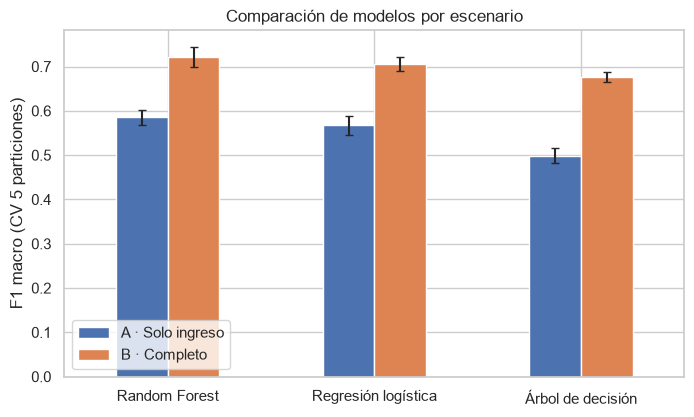

In [54]:
# Gráfico comparable: F1 macro (CV-5) por modelo y escenario, con desviación estándar
fig, ax = plt.subplots(figsize=(8, 4.5))
piv = resultados.pivot(index="Modelo", columns="Escenario", values="F1 macro CV-5 (media)")
err = resultados.pivot(index="Modelo", columns="Escenario", values="F1 macro CV-5 (desv)")
piv.plot(kind="bar", yerr=err, capsize=3, ax=ax)
ax.set_ylabel("F1 macro (CV 5 particiones)"); ax.set_xlabel(""); ax.set_title("Comparación de modelos por escenario")
plt.xticks(rotation=0); ax.legend(title="")
fig.savefig(FIG / "07_comparacion_modelos.png", dpi=150, bbox_inches="tight"); plt.show()

Mejor modelo (escenario B): Random Forest 

              precision    recall  f1-score   support

     Dropout       0.84      0.71      0.77       284
    Enrolled       0.46      0.64      0.54       159
    Graduate       0.87      0.83      0.85       442

    accuracy                           0.76       885
   macro avg       0.72      0.73      0.72       885
weighted avg       0.79      0.76      0.77       885



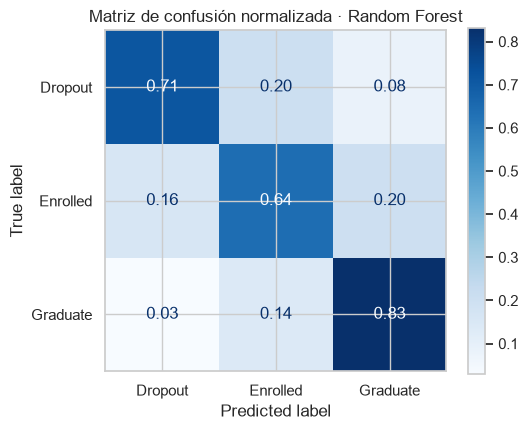

In [55]:
# Mejor modelo del escenario B según F1 macro (test): matriz de confusión e informe por clase
mejor = resultados[resultados["Escenario"] == "B · Completo"].sort_values("F1 macro (test)", ascending=False).iloc[0]["Modelo"]
pipe, pred, cols = ajustados[("B · Completo", mejor)]
print("Mejor modelo (escenario B):", mejor, "\n")
print(classification_report(y_te, pred))
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay.from_predictions(y_te, pred, normalize="true", cmap="Blues", ax=ax, values_format=".2f")
ax.set_title(f"Matriz de confusión normalizada · {mejor}")
fig.savefig(FIG / "08_matriz_confusion.png", dpi=150, bbox_inches="tight"); plt.show()

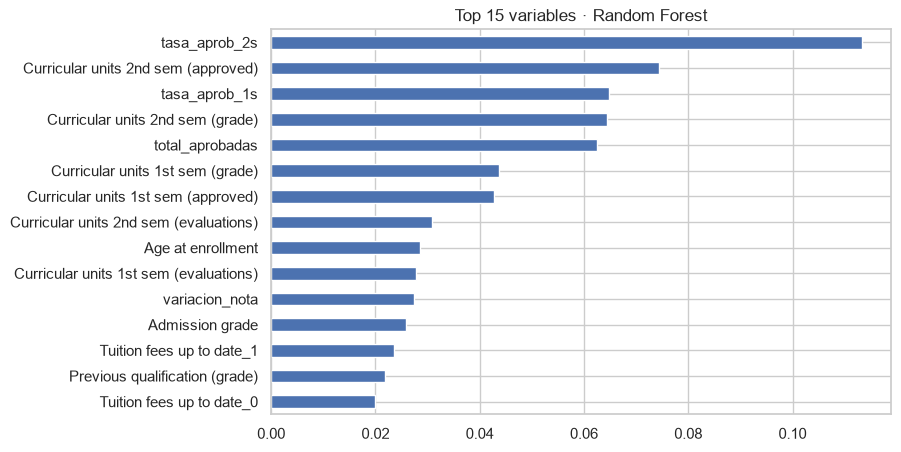

,importancia
tasa_aprob_2s,0.1133
Curricular units 2nd sem (approved),0.0744
tasa_aprob_1s,0.0649
Curricular units 2nd sem (grade),0.0644
total_aprobadas,0.0626
Curricular units 1st sem (grade),0.0437
Curricular units 1st sem (approved),0.0428
Curricular units 2nd sem (evaluations),0.0308
Age at enrollment,0.0285
Curricular units 1st sem (evaluations),0.0278


In [56]:
# Importancia de variables (Random Forest, escenario B)
rf_pipe, _, rf_cols = ajustados[("B · Completo", "Random Forest")]
nombres = rf_pipe.named_steps["prep"].get_feature_names_out()
imp = pd.Series(rf_pipe.named_steps["modelo"].feature_importances_, index=nombres).sort_values(ascending=False).head(15)
imp.index = [i.replace("num__", "").replace("cat__", "") for i in imp.index]
fig, ax = plt.subplots(figsize=(8, 5))
imp[::-1].plot(kind="barh", ax=ax); ax.set_title("Top 15 variables · Random Forest")
fig.savefig(FIG / "09_importancia_variables.png", dpi=150, bbox_inches="tight"); plt.show()
imp.round(4).to_frame("importancia")

**Interpretación (completar):** ¿qué modelo gana y por cuánto? ¿Cuánto mejora el escenario B frente al A? ¿Qué clase se confunde más (suele ser *Enrolled*)? ¿Qué variables pesan más y qué significa para la tutoría?

# 9. Clustering con K-means (análisis descriptivo)
Se agrupan los estudiantes por sus variables numéricas estandarizadas **sin usar la etiqueta**; después se compara cada grupo con la clase real para describir perfiles de riesgo.

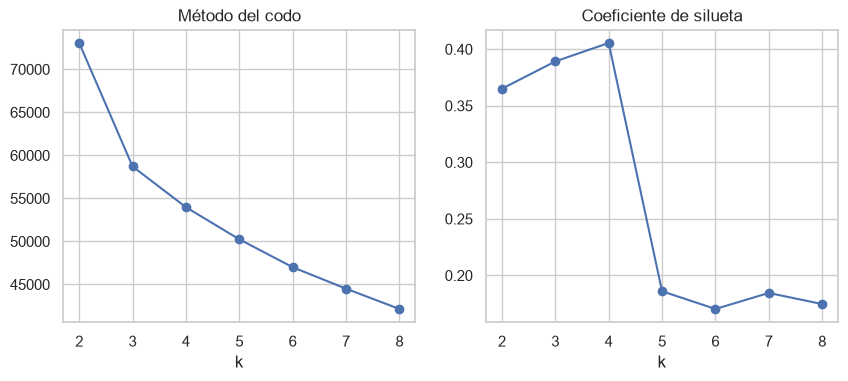

k con mayor silueta: 4


In [57]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

Z = StandardScaler().fit_transform(df[num_cols])
ks = range(2, 9)
inercia, sil = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(Z)
    inercia.append(km.inertia_); sil.append(silhouette_score(Z, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].plot(list(ks), inercia, marker="o"); axes[0].set_title("Método del codo"); axes[0].set_xlabel("k")
axes[1].plot(list(ks), sil, marker="o"); axes[1].set_title("Coeficiente de silueta"); axes[1].set_xlabel("k")
fig.savefig(FIG / "10_kmeans_codo_silueta.png", dpi=150, bbox_inches="tight"); plt.show()
print("k con mayor silueta:", list(ks)[int(np.argmax(sil))])

In [58]:
K = 3   # <-- ajusta según codo/silueta y tu criterio; justifícalo en el documento
km = KMeans(n_clusters=K, n_init=10, random_state=RANDOM_STATE).fit(Z)
df["cluster"] = km.labels_

clave = [age, adm, a1, g1, "tasa_aprob_1s", "total_aprobadas"]
perfil = df.groupby("cluster")[clave].mean().round(2)
perfil["n"] = df["cluster"].value_counts().sort_index()
riesgo = pd.crosstab(df["cluster"], df[TARGET], normalize="index").mul(100).round(1)
perfil.to_csv(TAB / "perfiles_kmeans.csv"); riesgo.to_csv(TAB / "kmeans_vs_objetivo.csv")
display(perfil); display(riesgo)

,Age at enrollment,Admission grade,Curricular units 1st sem (approved),Curricular units 1st sem (grade),tasa_aprob_1s,total_aprobadas,n
cluster,,,,,,,
0,22.12,126.97,5.32,12.75,0.86,10.53,3242
1,25.79,126.21,0.55,2.70,0.10,0.64,927
2,28.64,129.93,12.05,12.69,0.89,22.41,255


Target,Dropout,Enrolled,Graduate
cluster,,,
0,18.6,20.8,60.6
1,82.5,9.3,8.2
2,20.8,12.9,66.3


**Interpretación (completar):** nombra cada grupo (p. ej. *rendimiento alto*, *en riesgo*) según su perfil y su % de *Dropout*, y propón una acción de apoyo para el grupo de mayor riesgo.

# 10. Lista de verificación final (guía UEA)
- [ ] Problema, ≥3 objetivos específicos, alcance, justificación con ≥2 referencias y elevator pitch (≤150 palabras)
- [ ] Dataset ≥1000 registros y ≥5 variables, con fuente verificable
- [ ] Descriptivas + ≥3 visualizaciones · % nulos · duplicados (n y %) · atípicos
- [ ] Limpieza, transformaciones documentadas y ≥2 variables derivadas
- [ ] ≥3 técnicas, parámetros, partición train/test (80/20) y tabla comparativa
- [ ] ≥2 métricas, validación cruzada (5 particiones), tablas/gráficos e interpretación
- [ ] Código en GitHub con README · artículo IEEE short paper dentro del PDF único
- [ ] Bibliografía APA 7 · anexos (capturas, enlace al repo)